# **Testing the model prediction per field qualitatively**

In [1]:
from normalisation import preprocess, postprocess

In [2]:
# !pip install the_well[benchmark]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from einops import rearrange
from tqdm import tqdm
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

from the_well.benchmark.metrics import VRMSE
from the_well.data import WellDataset
from the_well.benchmark.models.unet_convnext import UNetConvNext

device = "cuda"
base_path = "./datasets"  # path/to/storage

/home/franklin/miniconda3/envs/mlearning/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
# Load the dataset
dataset_test = WellDataset(
    well_base_path = f'{base_path}/datasets',
    well_dataset_name = 'active_matter',
    well_split_name = "test",
    n_steps_input = 4,
    n_steps_output = 1,
    use_normalization = False
)

In [4]:
# Extract the number of fields
F = dataset_test.metadata.n_fields
print(F)

11


In [5]:
# Remember the key associated to each field
field_names_tmp = dataset_test.field_names

field_names_tmp2 = [
    name for group in field_names_tmp.values() for name in group
]

field_names = {}

for id in range(len(field_names_tmp2)):
    field_names[id] = field_names_tmp2[id]

print(field_names)

{0: 'concentration', 1: 'velocity_x', 2: 'velocity_y', 3: 'D_xx', 4: 'D_xy', 5: 'D_yx', 6: 'D_yy', 7: 'E_xx', 8: 'E_xy', 9: 'E_yx', 10: 'E_yy'}


In [6]:
class CNextbaseline(nn.Module):
    def __init__(self,
                 in_channels: int,
                 out_channels: int,
                 initial_dimension: int,
                 up_down_blocks: int,
                 blocks_per_stage: int,
                 bottleneck_blocks: int,
                 spatial_resolution: tuple,
                 spatial_dims: int=2):
        
        super().__init__()
        
        self.model = UNetConvNext(
            dim_in = in_channels,
            dim_out = out_channels,
            n_spatial_dims = spatial_dims,
            spatial_resolution = spatial_resolution,
            stages = up_down_blocks,
            blocks_per_stage = blocks_per_stage,
            blocks_at_neck = bottleneck_blocks,
            init_features = initial_dimension 
        )
    
    def forward(self, x):
        return self.model(x)

In [7]:
# Set the model
model_cnet = CNextbaseline(in_channels=4*F,
                           out_channels=1*F,
                           initial_dimension=42,
                           blocks_per_stage=2,
                           up_down_blocks=4,
                           bottleneck_blocks=1,
                           spatial_resolution=(256,256)).to(device)


model_cnet_phys = CNextbaseline(in_channels=4*F,
                           out_channels=1*F,
                           initial_dimension=42,
                           blocks_per_stage=2,
                           up_down_blocks=4,
                           bottleneck_blocks=1,
                           spatial_resolution=(256,256)).to(device)

In [8]:
# Load the weights into the model
stats = torch.load("./model_UNetConvNext_stats/trained_UNetConvNext_epoch_9.pth")
model_cnet.load_state_dict(stats)

stats_phys = torch.load("./model_UNetConvNext_phys_stats/trained_UNetConvNext_phys_best.pth")
model_cnet_phys.load_state_dict(stats_phys)

<All keys matched successfully>

## Visualisation of the results

In [9]:
item_id = 1000

model_cnet.eval()
model_cnet_phys.eval()

snap_in= dataset_test[item_id]["input_fields"]
ground_truth= dataset_test[item_id]["output_fields"]

In [10]:
# Normalise the input
snap_in = snap_in.to(device)
snap_in = preprocess(snap_in)
snap_in = rearrange(snap_in, "Ti Lx Ly F -> 1 (Ti F) Lx Ly")

In [11]:
prediction = model_cnet(snap_in)
prediction = rearrange(prediction, "1 (To F) Lx Ly -> To Lx Ly F", F=11)
prediction = postprocess(prediction)

prediction_phys = model_cnet_phys(snap_in)
prediction_phys = rearrange(prediction_phys, "1 (To F) Lx Ly -> To Lx Ly F", F=11)
prediction_phys = postprocess(prediction_phys)

In [12]:
# De-normalise input
snap_in = rearrange(snap_in, "1 (Ti F) Lx Ly -> Ti Lx Ly F", F=11)
snap_in = postprocess(snap_in)

snap_in = snap_in.detach()
snap_in = snap_in.to('cpu')

In [13]:
# Move prediction from cuda to cpu
prediction = prediction.detach()
prediction = prediction.to('cpu')

prediction_phys = prediction_phys.detach()
prediction_phys = prediction_phys.to('cpu')

## **Density testing**

In [14]:
f_id = 0
n_in = snap_in[:,:,:,f_id].shape[0]
n_out = ground_truth[:,:,:,f_id].shape[0]

In [15]:
print(snap_in[:,:,:,f_id].shape)

torch.Size([4, 256, 256])


In [16]:
# Density
minima = ground_truth[0,:,:,f_id].min()
maxima = ground_truth[0,:,:,f_id].max()

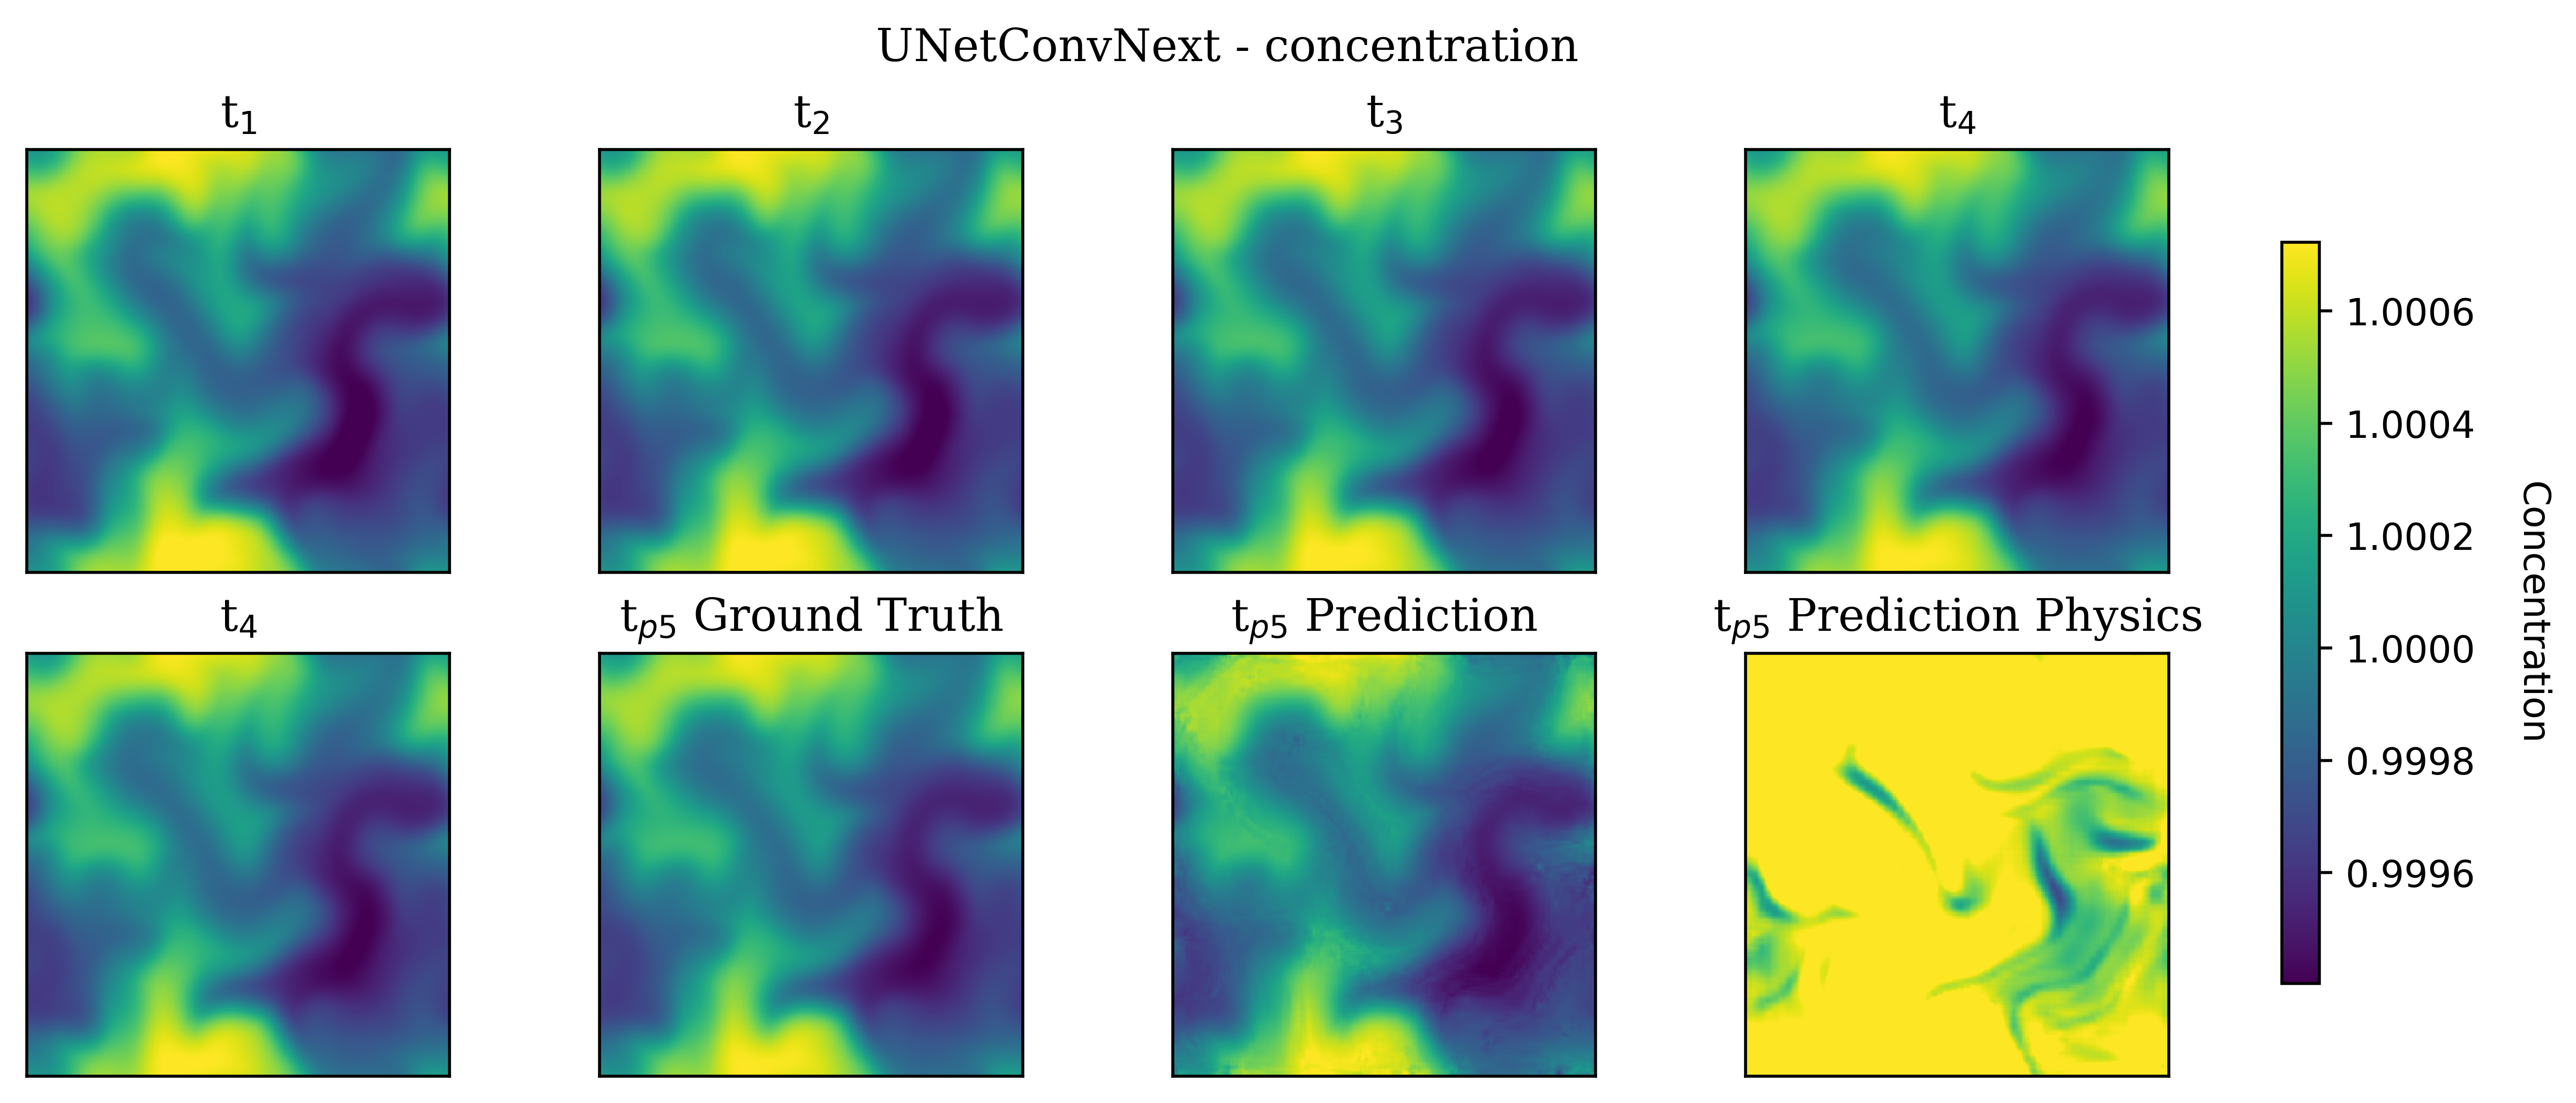

In [17]:
fig, axs = plt.subplots(
    nrows=2, 
    ncols=4, 
    figsize=(10, 4),
    dpi = 500,
    sharex=True, 
    sharey=True,
    constrained_layout=True
)

#fig, axs = plt.subplots(1, 3, figsize = (10, 4), dpi = 500)

axs[0,0].imshow(snap_in[0,:,:,f_id], vmin = minima, vmax = maxima)   
axs[0,0].set_xticks([])
axs[0,0].set_yticks([])
axs[0,0].set_title(r"t$_1$", family = 'serif')

axs[0,1].imshow(snap_in[1,:,:,f_id], vmin = minima, vmax = maxima)   
axs[0,1].set_xticks([])
axs[0,1].set_yticks([])
axs[0,1].set_title(r"t$_2$", family = 'serif')

axs[0,2].imshow(snap_in[2,:,:,f_id], vmin = minima, vmax = maxima)   
axs[0,2].set_xticks([])
axs[0,2].set_yticks([])
axs[0,2].set_title(r"t$_3$", family = 'serif')

axs[0,3].imshow(snap_in[3,:,:,f_id], vmin = minima, vmax = maxima)   
axs[0,3].set_xticks([])
axs[0,3].set_yticks([])
axs[0,3].set_title(r"t$_4$", family = 'serif')

axs[1,0].imshow(snap_in[3,:,:,f_id], vmin = minima, vmax = maxima)   
axs[1,0].set_xticks([])
axs[1,0].set_yticks([])
axs[1,0].set_title(r"t$_4$", family = 'serif')

cmap1 = axs[1,1].imshow(ground_truth[0,:,:,f_id], vmin = minima, vmax = maxima)   
axs[1,1].set_xticks([])
axs[1,1].set_yticks([])
axs[1,1].set_title(r"t$_{p5}$ Ground Truth", family = 'serif')
#fig.colorbar(cmap1, ax=axs[1,1])

cmap2 = axs[1,2].imshow(prediction[0, :, :, f_id], vmin = minima, vmax = maxima)
axs[1,2].set_xticks([])
axs[1,2].set_yticks([])
axs[1,2].set_title(r"t$_{p5}$ Prediction", family = 'serif')
#fig.colorbar(cmap2, ax=axs[1,2])

cmap3 = axs[1,3].imshow(prediction_phys[0, :, :, f_id], vmin = minima, vmax = maxima)
axs[1,3].set_xticks([])
axs[1,3].set_yticks([])
axs[1,3].set_title(r"t$_{p5}$ Prediction Physics", family = 'serif')
#fig.colorbar(cmap3, ax=axs[2])

#fig.colorbar(cmap1, ax=axs[1,1])
#fig.colorbar(cmap2, ax=axs[1,2])
#fig.colorbar(cmap3, ax=axs[1,3])

# Add a colorbar with a label
cbar = fig.colorbar(cmap2, ax=axs.ravel().tolist(), shrink=0.8, format="%.4f")
cbar.set_label("Concentration", rotation=270, labelpad=20)


plt.suptitle(f"UNetConvNext - {field_names[f_id]}", family = 'serif')
#plt.tight_layout()
plt.savefig(f"8_2_qualitative_testing_{field_names[f_id]}.png", bbox_inches='tight')
plt.show()

## **Exy testing**

In [18]:
f_id = 8
n_in = snap_in[:,:,:,f_id].shape[0]
n_out = ground_truth[:,:,:,f_id].shape[0]

In [19]:
print(snap_in[:,:,:,f_id].shape)

torch.Size([4, 256, 256])


In [20]:
# Density
minima = ground_truth[0,:,:,f_id].min()
maxima = ground_truth[0,:,:,f_id].max()

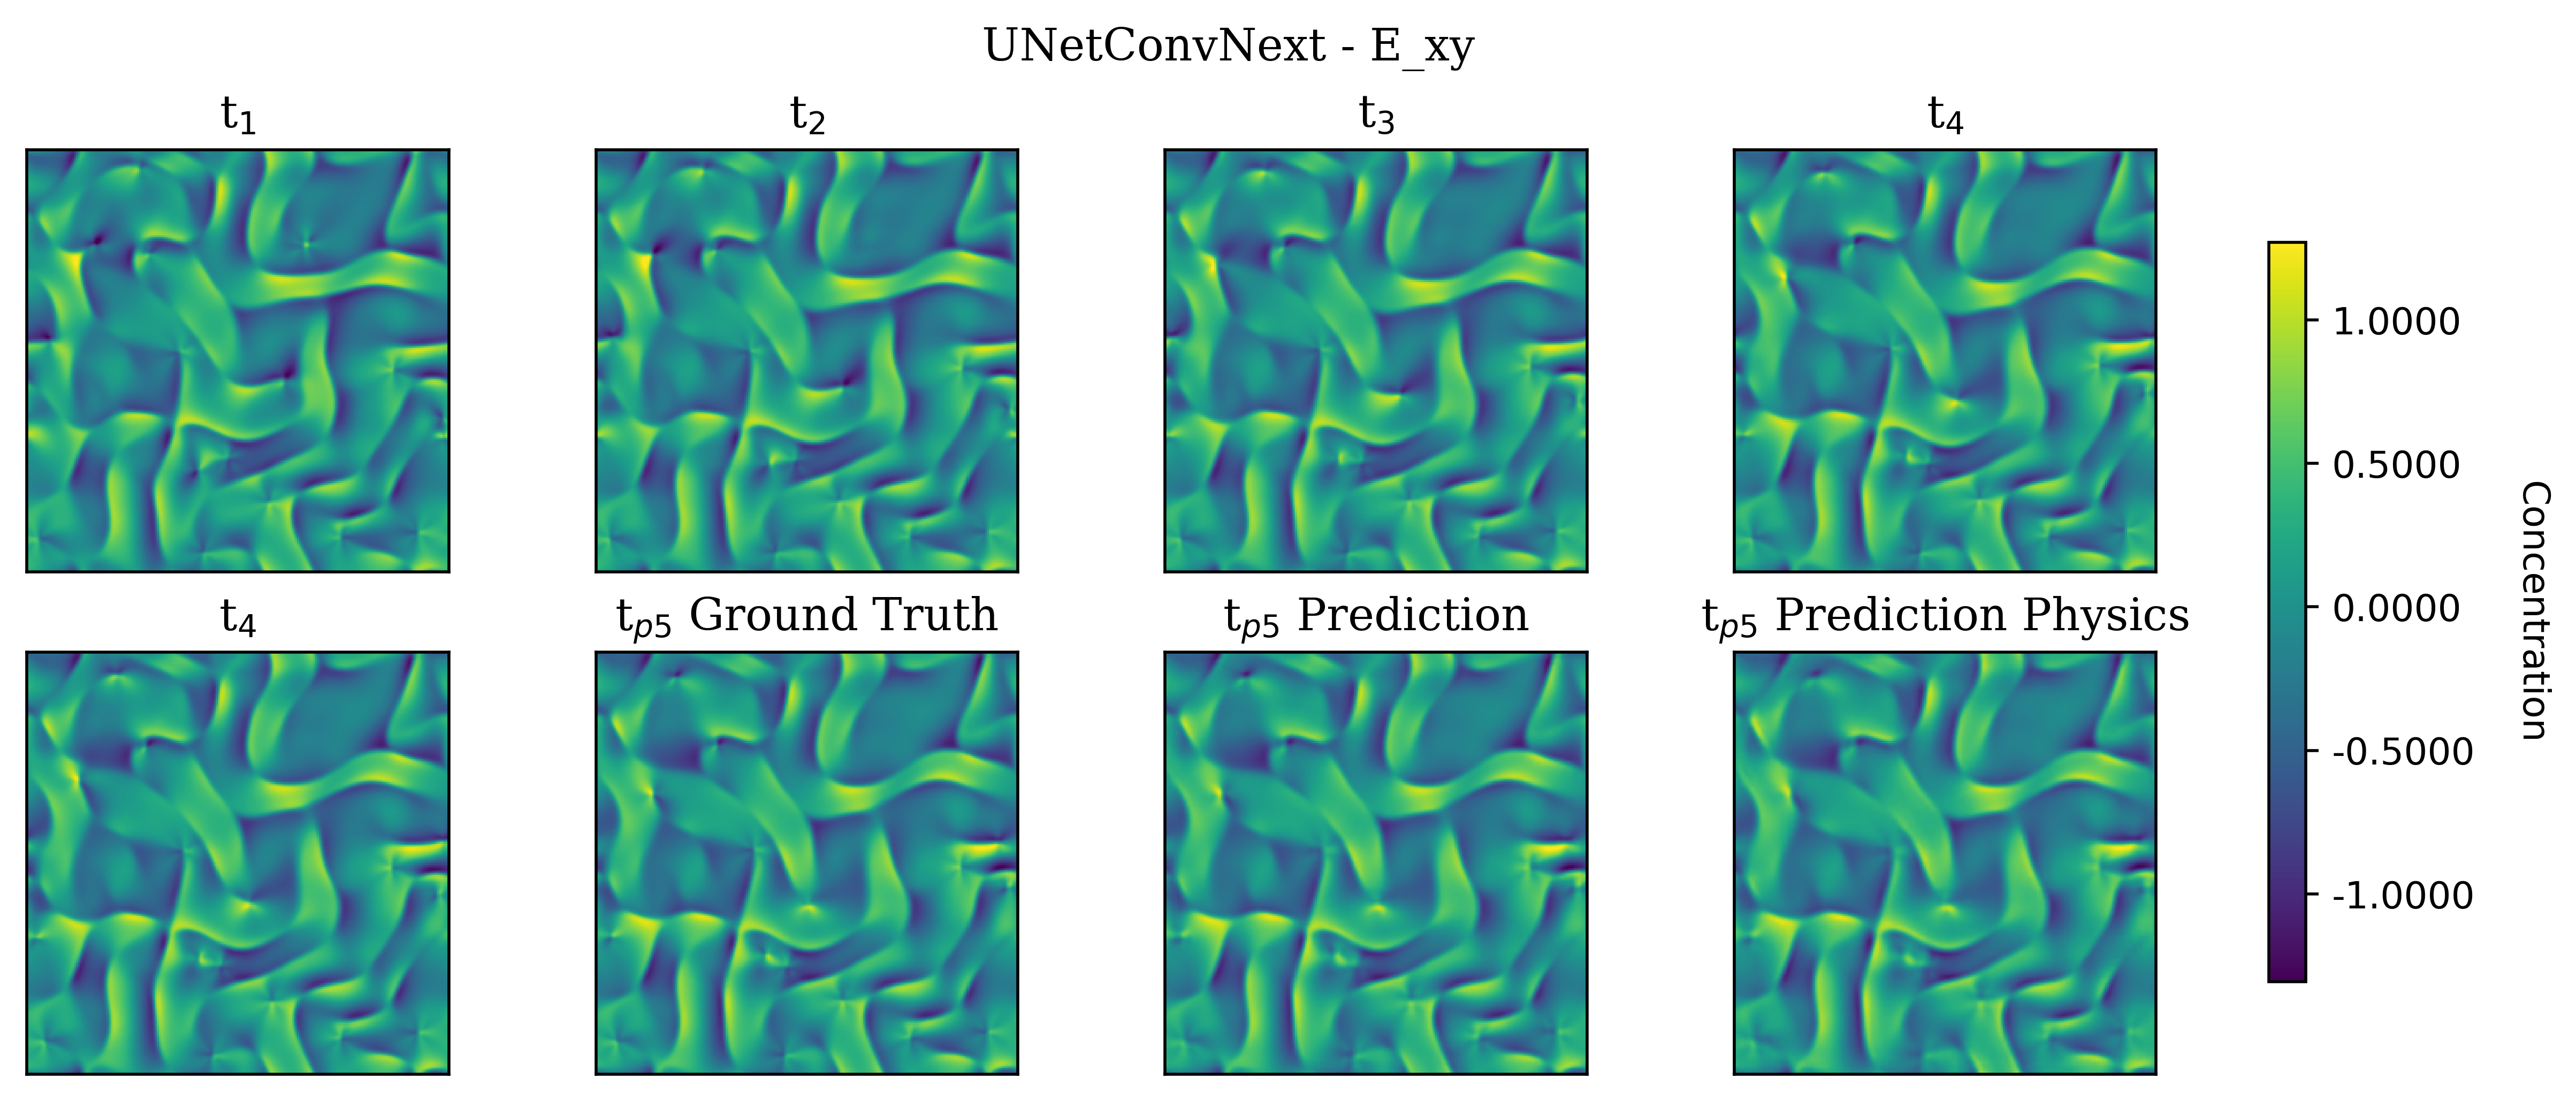

In [21]:
fig, axs = plt.subplots(
    nrows=2, 
    ncols=4, 
    figsize=(10, 4),
    dpi = 500,
    sharex=True, 
    sharey=True,
    constrained_layout=True
)

#fig, axs = plt.subplots(1, 3, figsize = (10, 4), dpi = 500)

axs[0,0].imshow(snap_in[0,:,:,f_id], vmin = minima, vmax = maxima)   
axs[0,0].set_xticks([])
axs[0,0].set_yticks([])
axs[0,0].set_title(r"t$_1$", family = 'serif')

axs[0,1].imshow(snap_in[1,:,:,f_id], vmin = minima, vmax = maxima)   
axs[0,1].set_xticks([])
axs[0,1].set_yticks([])
axs[0,1].set_title(r"t$_2$", family = 'serif')

axs[0,2].imshow(snap_in[2,:,:,f_id], vmin = minima, vmax = maxima)   
axs[0,2].set_xticks([])
axs[0,2].set_yticks([])
axs[0,2].set_title(r"t$_3$", family = 'serif')

axs[0,3].imshow(snap_in[3,:,:,f_id], vmin = minima, vmax = maxima)   
axs[0,3].set_xticks([])
axs[0,3].set_yticks([])
axs[0,3].set_title(r"t$_4$", family = 'serif')

axs[1,0].imshow(snap_in[3,:,:,f_id], vmin = minima, vmax = maxima)   
axs[1,0].set_xticks([])
axs[1,0].set_yticks([])
axs[1,0].set_title(r"t$_4$", family = 'serif')

cmap1 = axs[1,1].imshow(ground_truth[0,:,:,f_id], vmin = minima, vmax = maxima)   
axs[1,1].set_xticks([])
axs[1,1].set_yticks([])
axs[1,1].set_title(r"t$_{p5}$ Ground Truth", family = 'serif')
#fig.colorbar(cmap1, ax=axs[1,1])

cmap2 = axs[1,2].imshow(prediction[0, :, :, f_id], vmin = minima, vmax = maxima)
axs[1,2].set_xticks([])
axs[1,2].set_yticks([])
axs[1,2].set_title(r"t$_{p5}$ Prediction", family = 'serif')
#fig.colorbar(cmap2, ax=axs[1,2])

cmap3 = axs[1,3].imshow(prediction_phys[0, :, :, f_id], vmin = minima, vmax = maxima)
axs[1,3].set_xticks([])
axs[1,3].set_yticks([])
axs[1,3].set_title(r"t$_{p5}$ Prediction Physics", family = 'serif')
#fig.colorbar(cmap3, ax=axs[2])

# fig.colorbar(cmap1, ax=axs[1,1])
# fig.colorbar(cmap2, ax=axs[1,2])
# fig.colorbar(cmap3, ax=axs[1,3])

# Add a colorbar with a label
cbar = fig.colorbar(cmap2, ax=axs.ravel().tolist(), shrink=0.8, format="%.4f")
cbar.set_label("Concentration", rotation=270, labelpad=20)


plt.suptitle(f"UNetConvNext - {field_names[f_id]}", family = 'serif')
#plt.tight_layout()
plt.savefig(f"8_2_qualitative_testing_{field_names[f_id]}.png", bbox_inches='tight')
plt.show()

## **Testing the error (qualitatively)**

In [22]:
x_array = np.linspace(0, 10, 256)
dx = x_array[1] - x_array[0]
dy = dx # Both differentials the same as Lx = Ly
print(dx, dy)

0.0392156862745098 0.0392156862745098


In [23]:
def partials_velocities(prediction_batch):
    ''' 
    Takes the tensor of the shape B (To F) Lx Ly 
    and returns the tensor associated to the dvx/dy, dvx/dx and
    dvy/dy, dvy/dx components.
    '''
    # Choose the vx and vy components
    vx_id = [k for k, v in field_names.items() if v=='velocity_x']
    vy_id = [k for k, v in field_names.items() if v=='velocity_y']

    dvxdy_list = [] 
    dvxdx_list = []
    dvydy_list = [] 
    dvydx_list = []

    for id in range(prediction_batch.shape[0]):
        pred_sample_tmp = prediction_batch[id]

        vx_sample = pred_sample_tmp[vx_id[0]]
        vy_sample = pred_sample_tmp[vy_id[0]]

        # Spatial gradients
        dvxdx_tmp, dvxdy_tmp = torch.gradient(vx_sample, spacing = (dy, dx))
        dvydx_tmp, dvydy_tmp = torch.gradient(vy_sample, spacing = (dy, dx))

        dvxdy_list.append(dvxdy_tmp)
        dvxdx_list.append(dvxdx_tmp)
        dvydy_list.append(dvydy_tmp)
        dvydx_list.append(dvydx_tmp)
    
    return torch.stack(dvxdx_list, dim = 0), torch.stack(dvxdy_list, dim = 0), torch.stack(dvydx_list, dim = 0), torch.stack(dvydy_list, dim = 0) 

In [24]:
# Spatial gradients
dvxdy, dvxdx = torch.gradient(ground_truth[0,:,:,1])
dvydy, dvydx = torch.gradient(ground_truth[0,:,:,2])

div = dvxdx + dvydy

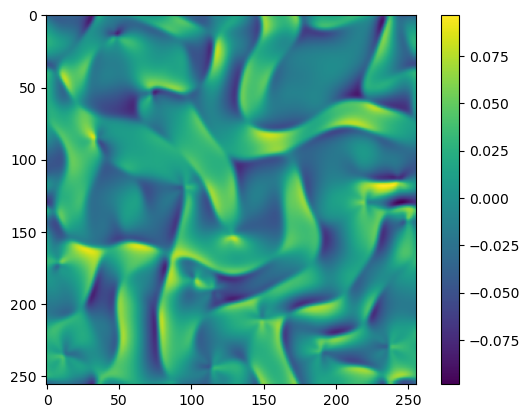

In [25]:
fig, ax = plt.subplots()
cmap = ax.imshow(div) #, vmin=-1, vmax=1)
plt.colorbar(cmap)

In [26]:
# Spatial gradients
dvxdy_p, dvxdx_p = torch.gradient(prediction_phys[0,:,:,1])
dvydy_p, dvydx_p = torch.gradient(prediction_phys[0,:,:,2])

div_p = dvxdx_p + dvydy_p

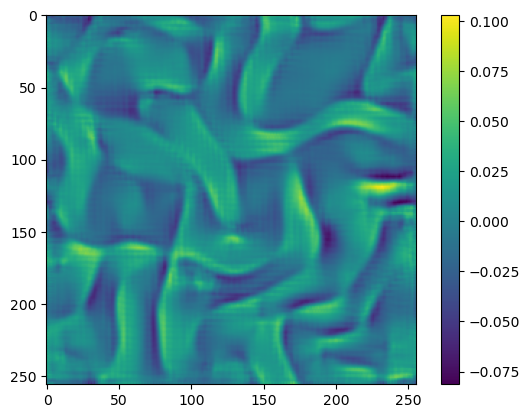

In [27]:
fig, ax = plt.subplots()
cmap = ax.imshow(div_p) #, vmin=-1, vmax=1)
plt.colorbar(cmap)

In [28]:
ground_truth.shape
print(prediction.shape)
print(prediction_phys.shape)

torch.Size([1, 256, 256, 11])
torch.Size([1, 256, 256, 11])


In [29]:
test1 = ground_truth[0, :, :, f_id] - prediction[0, :, :, f_id]
test2 = ground_truth[0, :, :, f_id] - prediction_phys[0, :, :, f_id]

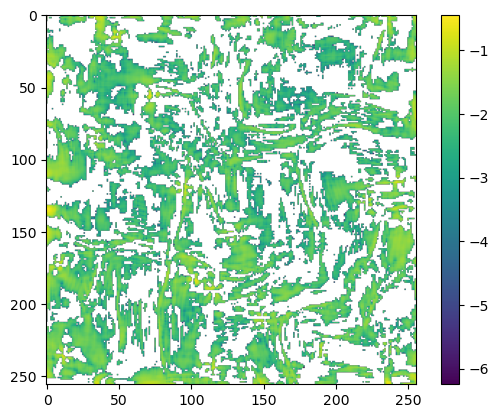

In [30]:
fig, ax = plt.subplots()
cmap = ax.imshow(torch.log10(test1))
plt.colorbar(cmap)
plt.show()

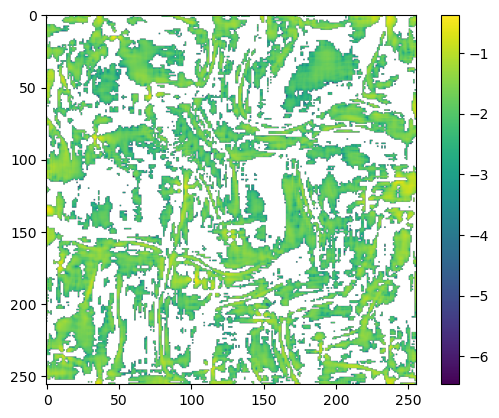

In [31]:
fig, ax = plt.subplots()
cmap = ax.imshow(torch.log10(test2))
plt.colorbar(cmap)
plt.show()

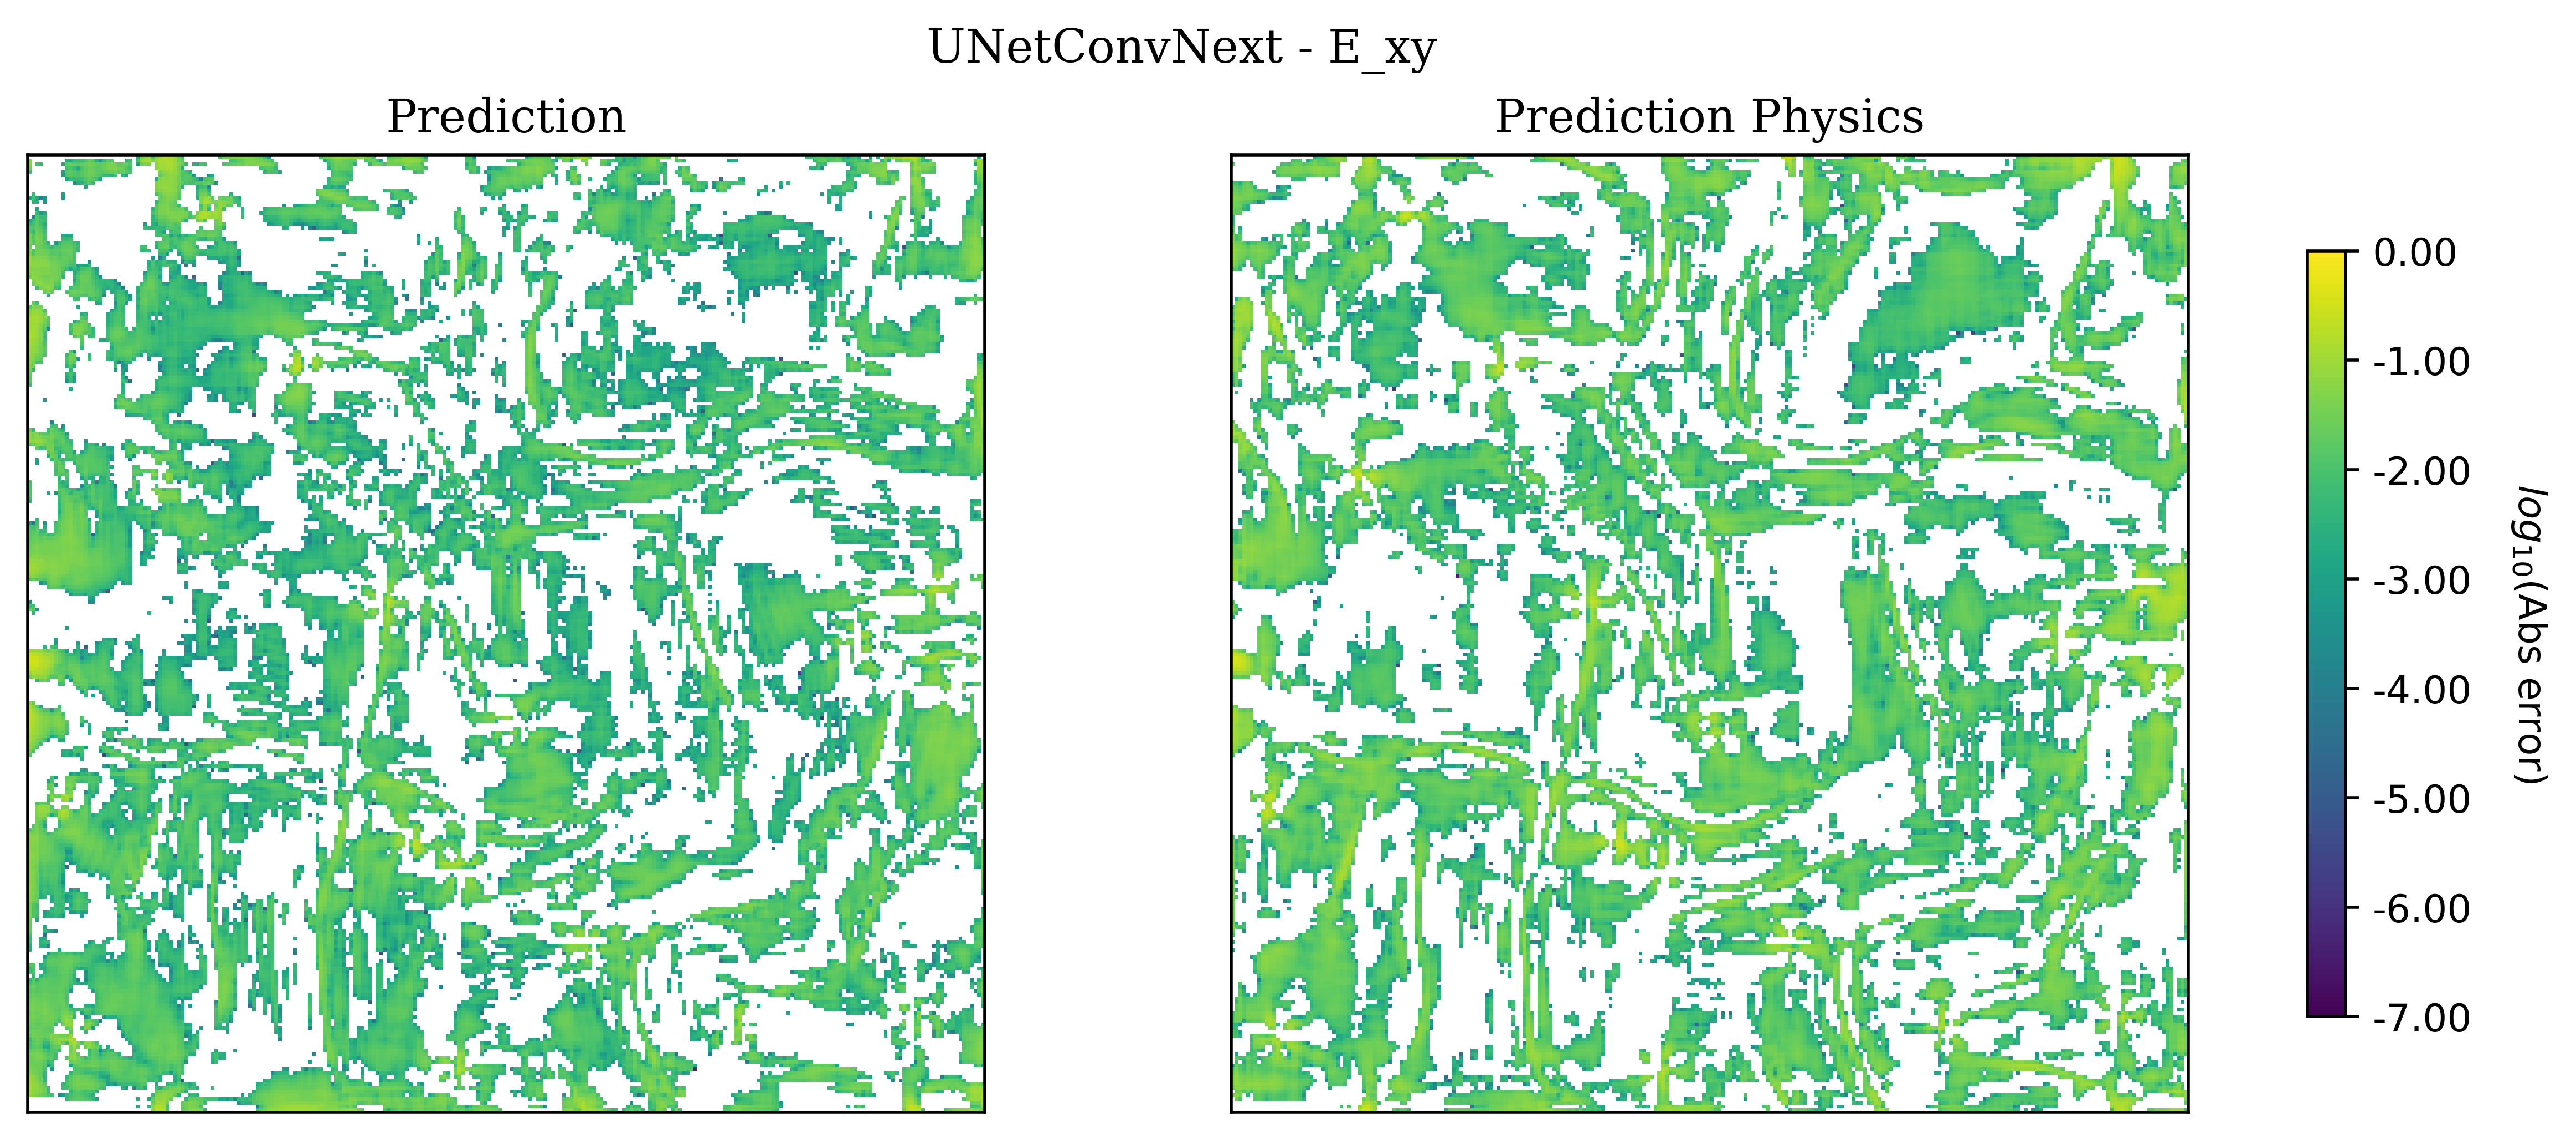

In [32]:
fig, axs = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 4),
    dpi = 500,
    sharex=True, 
    sharey=True,
    constrained_layout=True
)

#fig, axs = plt.subplots(1, 3, figsize = (10, 4), dpi = 500)

axs[0].imshow(torch.log10(test1), vmin = -7, vmax = 0)   
axs[0].set_xticks([])
axs[0].set_yticks([])
axs[0].set_title(r"Prediction", family = 'serif')

cmap1 = axs[1].imshow(torch.log10(test2), vmin = -7, vmax = 0)   
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[1].set_title(r"Prediction Physics", family = 'serif')

# Add a colorbar with a label
cbar = fig.colorbar(cmap1, ax=axs.ravel().tolist(), shrink=0.8, format="%.2f")
cbar.set_label(r"$log_{10}$(Abs error)", rotation=270, labelpad=20)

plt.suptitle(f"UNetConvNext - {field_names[f_id]}", family = 'serif')
#plt.tight_layout()
plt.savefig(f"8_3_qualitative_error_UNetConvNext_physics_pred_vs_phys_{field_names[f_id]}.png", bbox_inches='tight')
plt.show()